In [12]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import os
import json
import sys

In [13]:
# Get project root (2 levels up from current notebook location)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
 
# Define key directories
models_dir = os.path.join(project_root, 'Models')
trained_models_dir = os.path.join(project_root, 'Trained_Models')
simulated_data_dir = os.path.join(project_root, 'Simulated_Data')
results_dir = os.path.join(project_root, 'Results')
 
# Add Models to Python path
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)
 
# Verify paths exist
print("=" * 60)
print("PROJECT PATHS VERIFICATION")
print("=" * 60)
print(f"Project Root:      {project_root}")
print(f"Models Dir:        {models_dir} ✓" if os.path.exists(models_dir) else f"Models Dir:        {models_dir} ✗")
print(f"Trained Models:    {trained_models_dir} ✓" if os.path.exists(trained_models_dir) else f"Trained Models:    {trained_models_dir} ✗")
print(f"Simulated Data:    {simulated_data_dir} ✓" if os.path.exists(simulated_data_dir) else f"Simulated Data:    {simulated_data_dir} ✗")
print(f"Results Dir:       {results_dir} ✓" if os.path.exists(results_dir) else f"Results Dir:       {results_dir} ✗")
print("=" * 60)

PROJECT PATHS VERIFICATION
Project Root:      /Users/GraceCeline/Bachelorarbeit
Models Dir:        /Users/GraceCeline/Bachelorarbeit/Models ✓
Trained Models:    /Users/GraceCeline/Bachelorarbeit/Trained_Models ✓
Simulated Data:    /Users/GraceCeline/Bachelorarbeit/Simulated_Data ✓
Results Dir:       /Users/GraceCeline/Bachelorarbeit/Results ✓


In [14]:
elo_dir = os.path.join(os.getcwd(), '..', 'Models')  # adjust folder name
sys.path.append(elo_dir)
from ELO import Elo
import joblib

In [15]:
def load_pfa(scenario_id, base_dir=None):
    """
    Load a saved PFA model and its parameters for a given scenario.

    Args:
        scenario_id : scenario identifier (e.g. 1–6)
        base_dir    : optional override for the Trained_Models folder path

    Returns:
        model           : the loaded BKT model (via joblib)
        model_parameters: the loaded parameter dict (via JSON)
    """

    # Paths — must match exactly what was used in save_bkt
    model_path  = os.path.join(trained_models_dir, f'PFA_model_scenario_{scenario_id}.pkl')   # joblib model 
    # Load the model object
    model = joblib.load(model_path)
    coef_matrix = model.coef_
    model_parameters = coef_matrix.reshape(-1)

    print(f"[Scenario {scenario_id}] PFA model loaded ← {model_path}")
    return model, model_parameters

In [16]:
def calculate_p_op(n):
    return 0.5 - 1 / (2 * (n - 1))
    # Let n be the ratio of k_success and k_fail

In [17]:
def probability_pfa(pfa_parameters, num_skills, task_id, q_matrix, skill_levels, difficulty):
    """
    Compute probability of success using current skill levels and task difficulty.
    """
    logit = 0.0
    
    for skill in range(int(num_skills)):
        if q_matrix[skill, task_id] > 0.5:
            logit += float(skill_levels[skill])
    
    # difficulty_level = difficulty[task_id]
    difficulty_level = float(pfa_parameters[3 * num_skills + task_id])
    predictions_prob = 1.0 / ((1.0 + np.exp(-logit + difficulty_level)))
    
    return predictions_prob


def skill_update_pfa(pfa_parameters, num_skills, past_success, past_fail, pfa_skills):
    """
    Calculate PFA-based skill levels from accumulated success/failure counts.
    Does not modify input arrays, returns new skill levels.
    """
    # pfa_skills = np.zeros(num_skills)
    
    for skill in range(int(num_skills)):
        baseline = float(pfa_parameters[3 * skill])
        success_contribution = float(past_success[skill]) * float(pfa_parameters[3 * skill + 1])
        fail_contribution = float(past_fail[skill]) * float(pfa_parameters[3 * skill + 2])
        pfa_skills[skill] = baseline + success_contribution + fail_contribution
    
    return pfa_skills



In [18]:
def optimized_steps_to_mastery(
    pfa_parameters,
    initial_skill_level,
    q_matrix,
    difficulty,
    depends,
    k_success,
    n,
    num_tasks
):
    results = []
    all_skill_histories = []
    k_fail = 1 / n
    p_op = calculate_p_op(n)
    num_students = 50
    num_skills = len(initial_skill_level)
    print(f"Adjusted kappa with k_fail being {k_fail}, p_op = {p_op:.4f}")
    
    for student_id in range(num_students):
        # Step 1: Initialize skill levels for PFA and ELO for this student
        skill_levels_elo = initial_skill_level.copy()
        skill_levels_pfa = initial_skill_level.copy()
        
        # Step 2: Initialize past success/fail counts for each skill
        past_success = np.zeros(num_skills)
        past_fail = np.zeros(num_skills)
        
        step = 0
        reached_step = None
        skill_history = [skill_levels_elo.tolist()]
        task_probabilities = np.zeros(num_tasks)
        
        # Step 3: While mastery not reached
        while np.any(skill_levels_elo < 1.5) and step < 30:
            step += 1
            
            # Calculate probability for all tasks using PFA
            for task_id in range(num_tasks):
                task_probabilities[task_id] = probability_pfa(pfa_parameters, num_skills, task_id, q_matrix, skill_levels_pfa, difficulty)
            
            # Step 4: Select task with probability closest to p_op
            probability_differences = np.abs(task_probabilities - p_op)
            selected_task_id = np.argmin(probability_differences)
            if student_id == 0:
                print("DEBUG selected task ", selected_task_id)
            
            # Get skills needed for this task
            skills_needed = q_matrix[:, selected_task_id]
            
            # Update both PFA and ELO skills
            skill_levels_pfa = skill_update_pfa(pfa_parameters, num_skills, past_success, past_fail, skill_levels_pfa)
            skill_levels_elo, correctness = Elo.skill_update(
                difficulty[selected_task_id],
                skill_levels_elo,
                skills_needed,
                depends,
                k_success,
                k_fail
            )
            
            # Step 5: Update past success/fail counts for involved skills
            involved_skills = np.where(skills_needed == 1)[0]
            for skill in involved_skills:
                if correctness == 1:
                    past_success[int(skill)] += 1
                else:
                    past_fail[int(skill)] += 1
            
            skill_history.append(skill_levels_elo.tolist())
            if student_id == 0:
                print("DEBUG skill level: ",skill_levels_pfa.tolist())
            
            # Step 6: Check if mastery reached
            if reached_step is None and np.all(skill_levels_elo >= 1.5):
                reached_step = step
        
        results.append({
            "student_id": student_id + 1,
            "steps_to_mastery": reached_step,
            "p_op": p_op
        })
        last_skill_history = skill_history
    
    avg_steps = pd.DataFrame(results)["steps_to_mastery"].mean()
    std_steps = pd.DataFrame(results)["steps_to_mastery"].std()
    skill_history_array = np.array(last_skill_history)
    return avg_steps, std_steps, skill_history_array, p_op

In [19]:
def run_optimization_pfa(pfa_parameters, num_tasks, num_skills, q_matrix, difficulty, depends, init_skill_level, scenario_id):
    results = []
    
    average_step_lower_p_op, std_step_lower_p_op, skill_history_lower, p_op_2 = optimized_steps_to_mastery(
        pfa_parameters, init_skill_level.copy(), q_matrix, difficulty, depends, 1, 2, num_tasks
    )
    average_step_normal_p_op, std_step_normal_p_op, skill_history_normal, p_op_4 = optimized_steps_to_mastery(
        pfa_parameters, init_skill_level.copy(), q_matrix, difficulty, depends, 1, 4, num_tasks
    )
    average_step_higher_p_op, std_step_higher_p_op, skill_history_higher, p_op_6 = optimized_steps_to_mastery(
        pfa_parameters, init_skill_level.copy(), q_matrix, difficulty, depends, 1, 6, num_tasks
    )
    
    results.append({
        "scenario": scenario_id,
        "p_op_0.0_mean": average_step_lower_p_op,
        "p_op_0.0_std": std_step_lower_p_op,
        "p_op_0.33_mean": average_step_normal_p_op,
        "p_op_0.33_std": std_step_normal_p_op,
        "p_op_0.4_mean": average_step_higher_p_op,
        "p_op_0.4_std": std_step_higher_p_op,
    })
    
    results_table = pd.DataFrame(results)
    results_table.to_csv(f'../../Results/pfa_results_scenario_{scenario_id}.csv', index=False)
    print(results_table)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    data = [(skill_history_lower, f'p_op = {p_op_2:.4f}', 'o'),
            (skill_history_normal, f'p_op = {p_op_4:.4f}', 's'),
            (skill_history_higher, f'p_op = {p_op_6:.4f}', '^')]
    
    colors = [('blue', 'blue'), ('orange', 'green'), ('purple', 'brown')]
    
    for ax, (skill_hist, title, marker), (c1, c2) in zip(axes, data, colors):
        steps = range(skill_hist.shape[0])
        ax.plot(steps, skill_hist[:, 0], marker=marker, label='Skill 1', linewidth=2, color=c1)
        ax.plot(steps, skill_hist[:, 1], marker=marker, label='Skill 2', linewidth=2, color=c2)
        ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, label='Mastery Threshold')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Step')
        ax.set_ylabel('Skill Level')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'PFA Skill Mastery Progression — Scenario {scenario_id}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Start Optimizing

In [20]:
with open('../../elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

In [21]:
all_data = {}

level_skill   = [] 
mastery_level = 1.5
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
# k_success         = global_values["k_success"]
# k_fail            = global_values["k_fail"]

[Scenario 1] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_1.pkl
DEBUG SCENARIO {scenario_id}  [-0.77127943  0.78622426  0.57463289 -0.75879195  0.83922753  0.59480968
 -0.77127943 -0.75879195]
-------------- RESULTS FOR SCENARIO 1------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  1
DEBUG skill level:  [-0.7712794272143896, -0.7587919522675409]
DEBUG selected task  0
DEBUG skill level:  [-0.7712794272143896, -0.16398227397789988]
DEBUG selected task  0
DEBUG skill level:  [0.014944835737351947, -0.16398227397789988]
DEBUG selected task  1
DEBUG skill level:  [0.5895777223981311, -0.16398227397789988]
DEBUG selected task  1
DEBUG skill level:  [0.5895777223981311, 0.43082740431174116]
DEBUG selected task  1
DEBUG skill level:  [0.5895777223981311, 1.0256370826013823]
DEBUG selected task  0
DEBUG skill level:  [0.5895777223981311, 1.8648646076372328]
DEBUG selected task  0
DEBUG skill level:  [1.16421060905

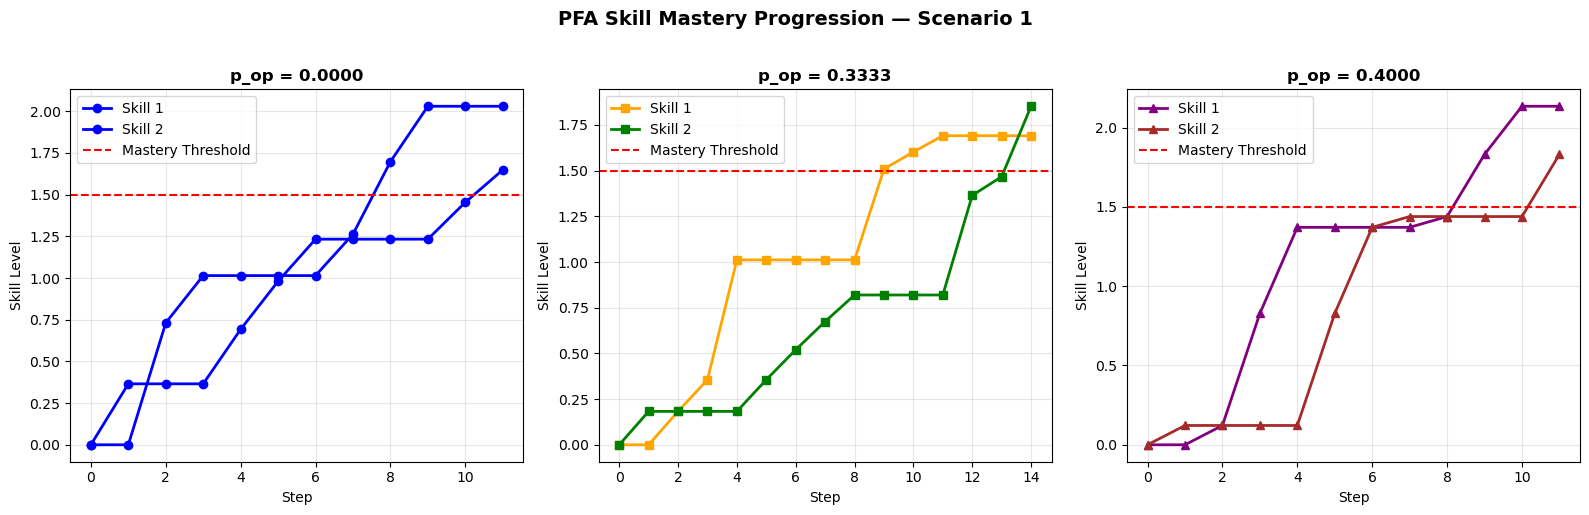

[Scenario 2] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_2.pkl
DEBUG SCENARIO {scenario_id}  [-0.74263956  0.22179528  0.25341009 -0.74263956  0.22179528  0.25341009
  0.67465774 -1.4172973 ]
-------------- RESULTS FOR SCENARIO 2------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  0
DEBUG skill level:  [-0.7426395616608439, -0.7426395616608439]
DEBUG selected task  0
DEBUG skill level:  [-0.48922947025233665, -0.48922947025233665]
DEBUG selected task  0
DEBUG skill level:  [-0.23581937884382942, -0.23581937884382942]
DEBUG selected task  0
DEBUG skill level:  [-0.014024096137817077, -0.014024096137817077]
DEBUG selected task  0
DEBUG skill level:  [0.20777118656819515, 0.20777118656819515]
DEBUG selected task  0
DEBUG skill level:  [0.4295664692742074, 0.4295664692742074]
DEBUG selected task  0
DEBUG skill level:  [0.6829765606827146, 0.6829765606827146]
Adjusted kappa with k_fail being 0.25, p_op = 0.333

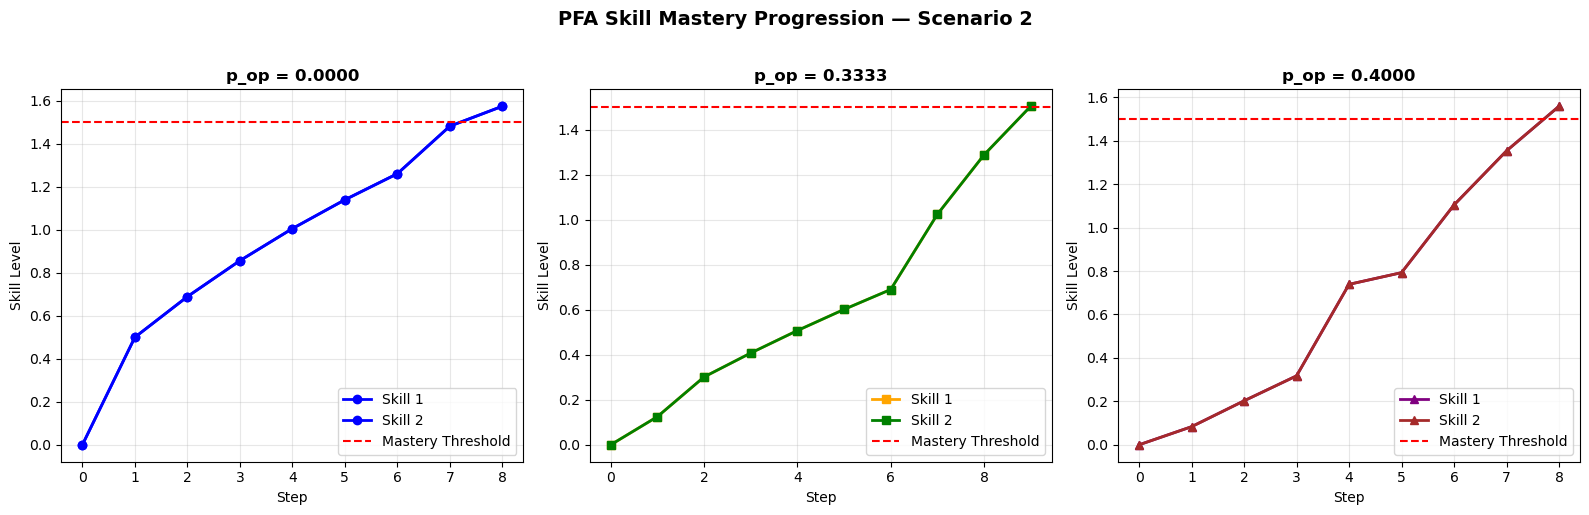

[Scenario 3] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_3.pkl
DEBUG SCENARIO {scenario_id}  [-0.23980915  0.44047447  0.3551522  -0.31134319  0.458514    0.38031311
  0.74276085  0.65391062 -0.98257001 -0.96525381]
-------------- RESULTS FOR SCENARIO 3------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  0
DEBUG skill level:  [-0.23980915264497138, -0.3113431890116095]
DEBUG selected task  0
DEBUG skill level:  [0.20066531376327895, -0.3113431890116095]
DEBUG selected task  1
DEBUG skill level:  [0.6411397801715293, -0.3113431890116095]
DEBUG selected task  1
DEBUG skill level:  [0.6411397801715293, 0.14717080832234553]
DEBUG selected task  1
DEBUG skill level:  [0.6411397801715293, 0.6056848056563006]
DEBUG selected task  0
DEBUG skill level:  [0.6411397801715293, 1.0641988029902558]
DEBUG selected task  0
DEBUG skill level:  [1.0816142465797798, 1.0641988029902558]
DEBUG selected task  0
DEBUG skill lev

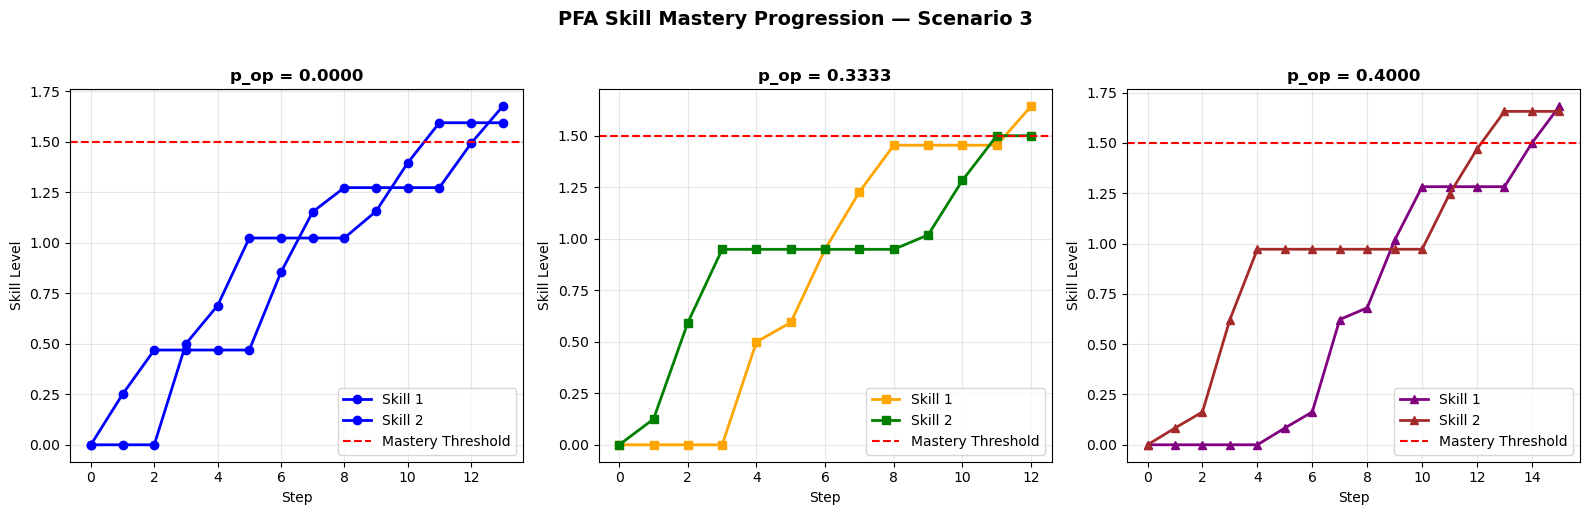

[Scenario 4] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_4.pkl
DEBUG SCENARIO {scenario_id}  [-0.77375654  0.22804873  0.3426601  -0.81333067  0.31017726  0.29525717
 -0.15466179 -0.19423593  0.8196578  -1.43875254]
-------------- RESULTS FOR SCENARIO 4------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  2
DEBUG skill level:  [-0.7737565363367217, -0.8133306676545212]
DEBUG selected task  2
DEBUG skill level:  [-0.5457078060849723, -0.5031534113695328]
DEBUG selected task  2
DEBUG skill level:  [-0.20304770228616076, -0.20789624466644108]
DEBUG selected task  2
DEBUG skill level:  [0.025001027965588618, 0.10228101161854719]
DEBUG selected task  2
DEBUG skill level:  [0.253049758217338, 0.41245826790353557]
Adjusted kappa with k_fail being 0.25, p_op = 0.3333
DEBUG selected task  2
DEBUG skill level:  [-0.7737565363367217, -0.8133306676545212]
DEBUG selected task  0
DEBUG skill level:  [-0.5457078060849723

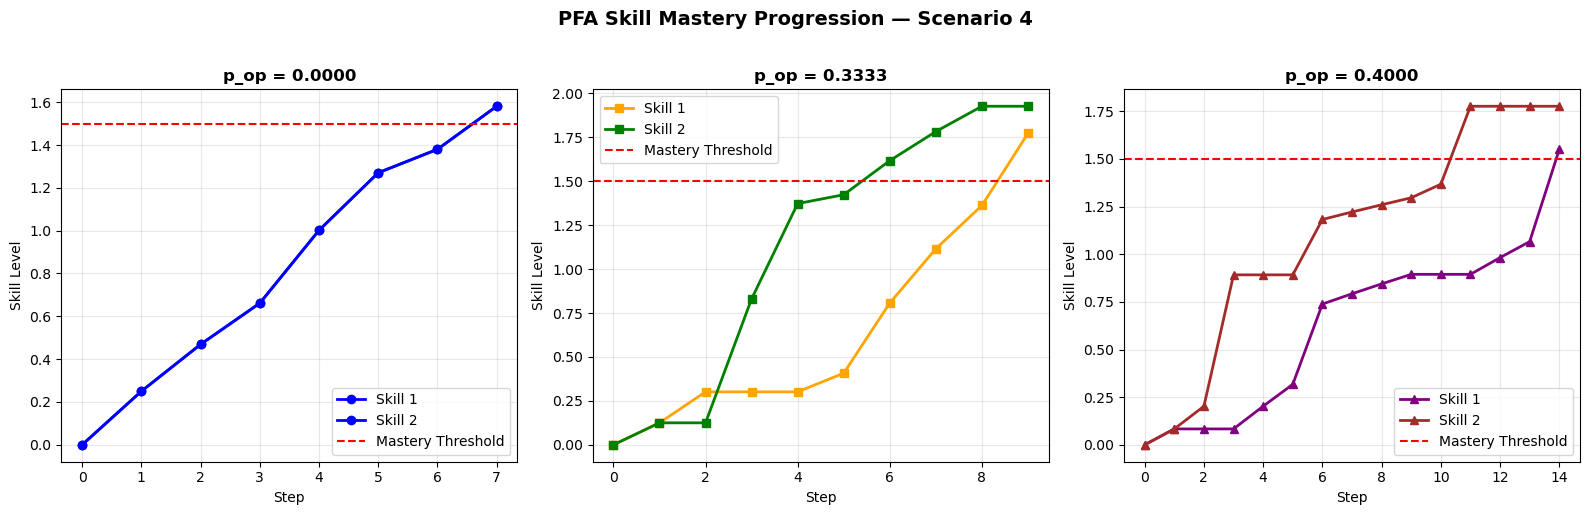

[Scenario 5] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_5.pkl
DEBUG SCENARIO {scenario_id}  [-0.55801605  0.2867106   0.23724084 -0.49660921  0.21662291  0.30390062
  1.27358311  1.18280928  0.51309564 -0.46221915 -0.31003849 -1.88247564]
-------------- RESULTS FOR SCENARIO 5------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  0
DEBUG skill level:  [-0.5580160529567538, -0.4966092107657641]
DEBUG selected task  0
DEBUG skill level:  [-0.2713054498085091, -0.4966092107657641]
DEBUG selected task  1
DEBUG skill level:  [0.015405153339735578, -0.4966092107657641]
DEBUG selected task  1
DEBUG skill level:  [0.015405153339735578, -0.19270858954412917]
DEBUG selected task  1
DEBUG skill level:  [0.015405153339735578, 0.023914321610833955]
DEBUG selected task  0
DEBUG skill level:  [0.015405153339735578, 0.24053723276579708]
DEBUG selected task  0
DEBUG skill level:  [0.3021157564879803, 0.24053723276579708]
DE

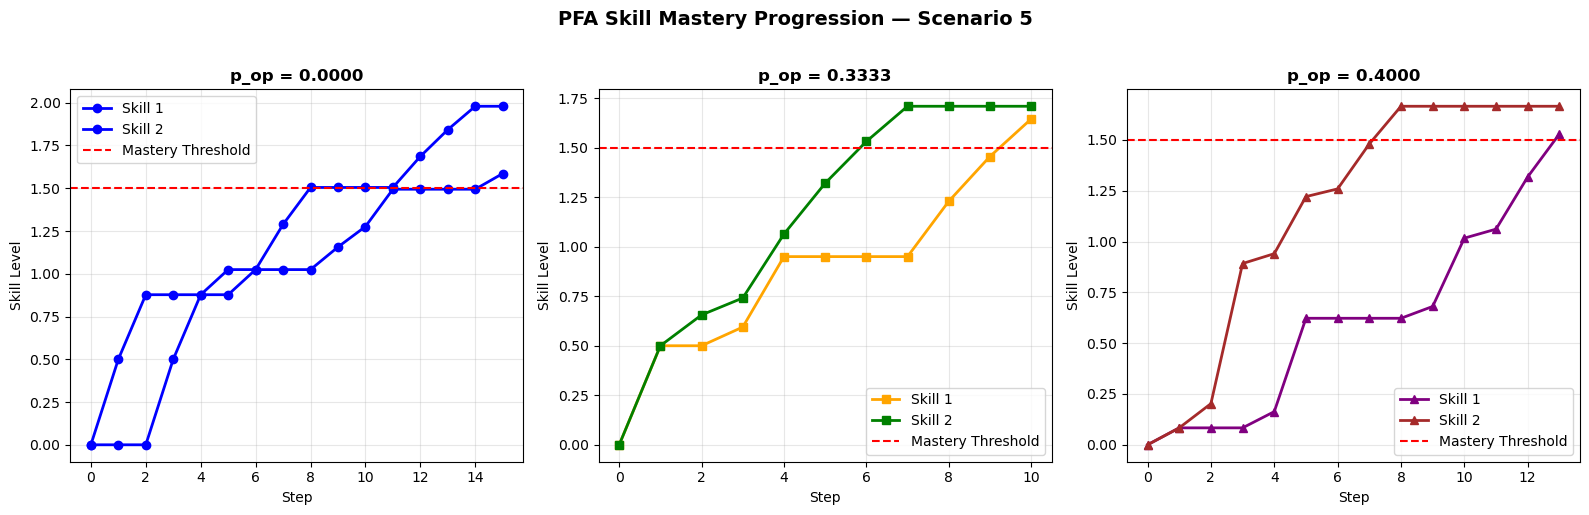

[Scenario 6] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_6.pkl
DEBUG SCENARIO {scenario_id}  [-1.16252437  0.45719188  0.58273729 -1.04102456  0.50911467  0.50256263
  1.34052907  1.33646208 -0.286905   -0.36213933 -2.21614845 -2.01534732]
-------------- RESULTS FOR SCENARIO 6------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  0
DEBUG skill level:  [-1.1625243680204795, -1.041024564571665]
DEBUG selected task  0
DEBUG skill level:  [-0.7053324911256085, -1.041024564571665]
DEBUG selected task  1
DEBUG skill level:  [-0.2481406142307374, -1.041024564571665]
DEBUG selected task  1
DEBUG skill level:  [-0.2481406142307374, -0.5384619318834941]
DEBUG selected task  1
DEBUG skill level:  [-0.2481406142307374, -0.03589929919532331]
DEBUG selected task  0
DEBUG skill level:  [-0.2481406142307374, 0.4732153708521035]
DEBUG selected task  0
DEBUG skill level:  [0.20905126266413365, 0.4732153708521035]
DEBUG selec

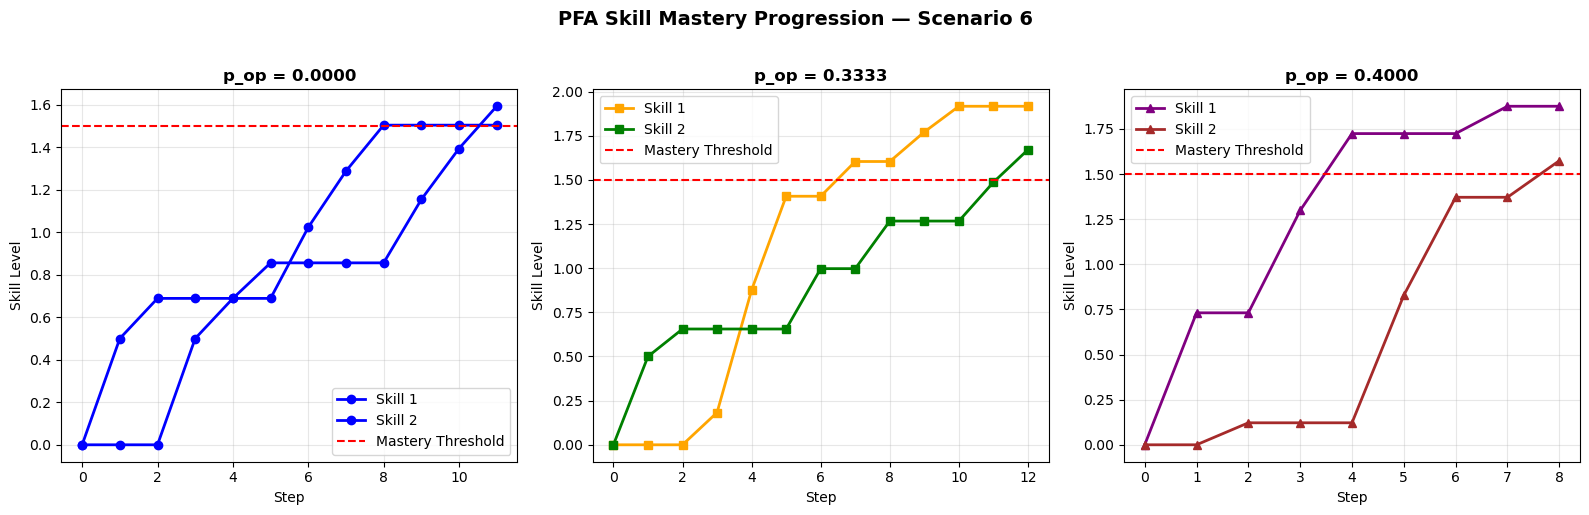

[Scenario 7] PFA model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/PFA_model_scenario_7.pkl
DEBUG SCENARIO {scenario_id}  [-0.83255459  0.16258313  0.15645262 -0.80079298  0.17484128  0.12155299
 -0.86808858  0.38749353  0.11593805 -0.22507243  1.25757968 -0.39376662
  1.08300267 -0.51571038 -0.30773721  1.16739753 -1.04161425]
-------------- RESULTS FOR SCENARIO 7------------------
Adjusted kappa with k_fail being 0.5, p_op = 0.0000
DEBUG selected task  1
DEBUG skill level:  [-0.8325545868672882, -0.8007929844923559, -0.8680885778510542]
DEBUG selected task  1
DEBUG skill level:  [-0.669971460258478, -0.8007929844923559, -0.8680885778510542]
DEBUG selected task  6
DEBUG skill level:  [-0.5135188354216077, -0.8007929844923559, -0.8680885778510542]
DEBUG selected task  6
DEBUG skill level:  [-0.5135188354216077, -0.679239990666397, -0.8680885778510542]
DEBUG selected task  3
DEBUG skill level:  [-0.5135188354216077, -0.5576869968404379, -0.8680885778510542]
DEBUG selected 

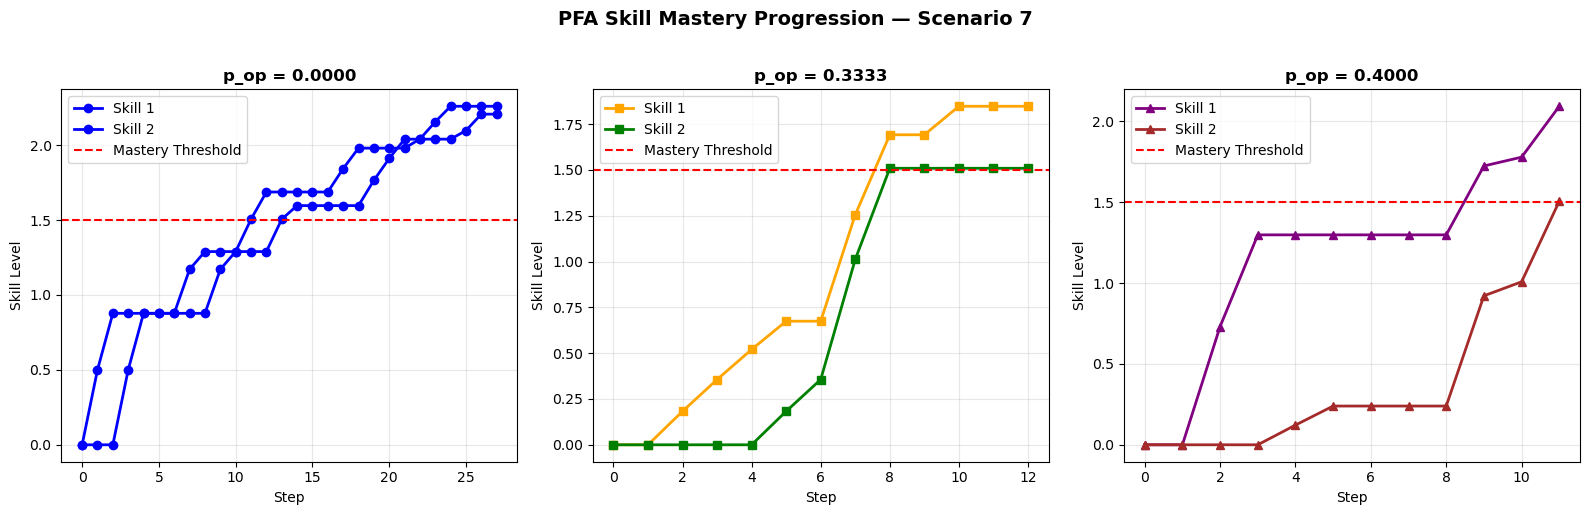

In [28]:
import sys

for scenario in scenarios:
        scenario_id    = scenario["id"]
        num_tasks      = scenario["num_tasks"]
        num_skills     = scenario["num_skills"]
        init_skill_level  = np.zeros(num_skills)
        difficulty_level = np.array(scenario["difficulty_level"])
        q_matrix       = np.array(scenario["q_matrix"])
        depends = np.array(scenario["depends"])
        
        pfa, pfa_params = load_pfa(scenario_id, num_tasks)
        print("DEBUG SCENARIO {scenario_id} ", pfa_params)
        
        print(f"-------------- RESULTS FOR SCENARIO {scenario_id}------------------")
        run_optimization_pfa(pfa_params, num_tasks, num_skills, q_matrix, difficulty_level, depends, init_skill_level, scenario_id)